In [1]:
!pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
pipeline = joblib.load("../models/attrition_pipeline.pkl")

In [4]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [5]:
preprocessor = pipeline.named_steps["preprocessor"]

model = pipeline.named_steps["classifier"]

In [6]:
X_test_transformed = preprocessor.transform(X_test)

In [7]:
feature_names = preprocessor.get_feature_names_out()

In [8]:
explainer = shap.TreeExplainer(model)

In [9]:
shap_values = explainer.shap_values(X_test_transformed)

In [10]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [19]:
print(shap_values.shape)

print(X_test_transformed.shape)

print(len(feature_names))

(294, 51, 2)
(294, 51)
51


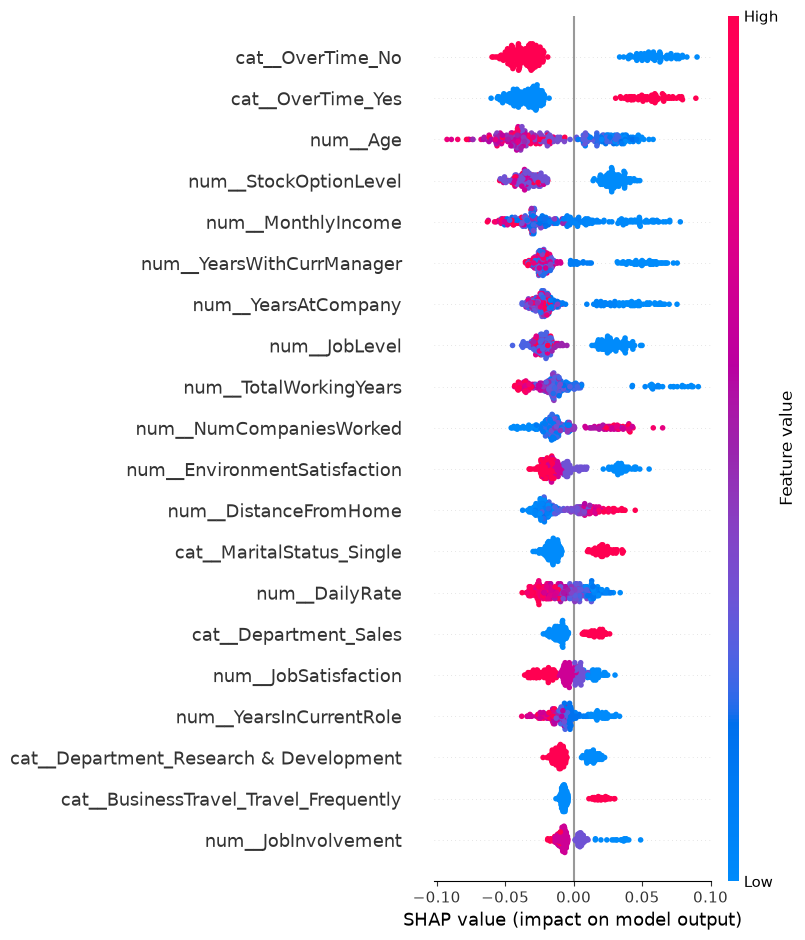

In [20]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names
)

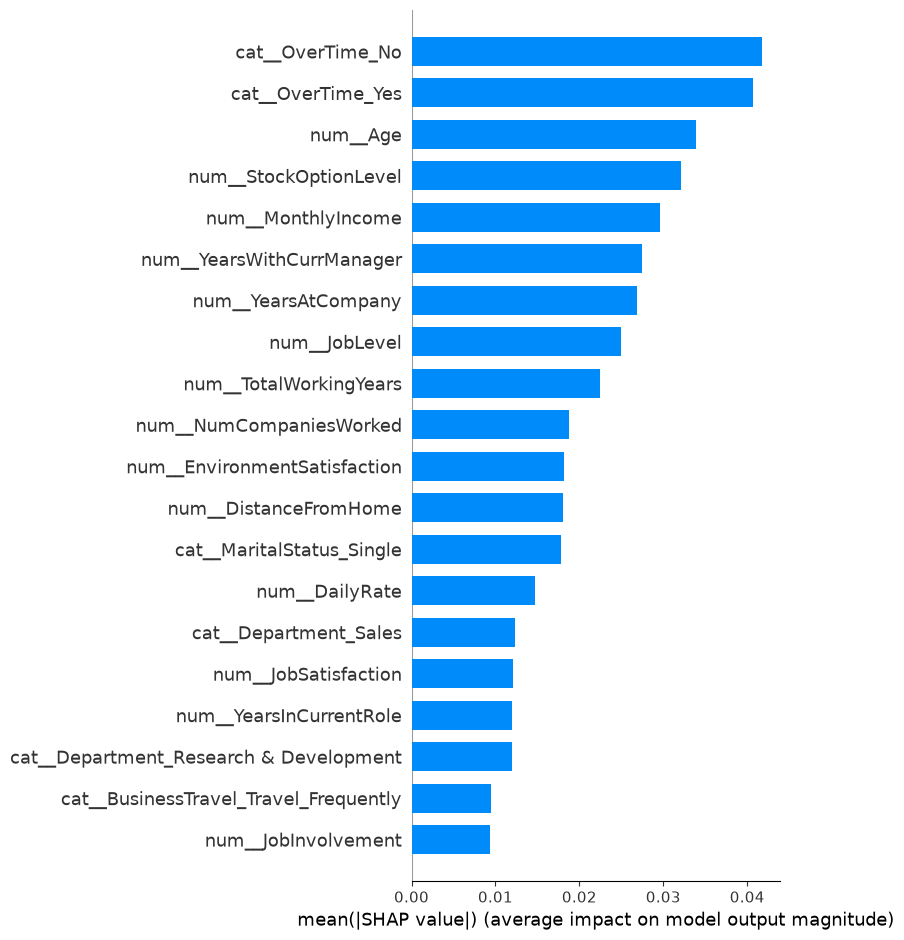

In [21]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [23]:
employee_index = 0

employee_shap = pd.DataFrame({

    "Feature": feature_names,

    "SHAP Value": shap_values[employee_index, :, 1]

})

employee_shap["Absolute"] = employee_shap["SHAP Value"].abs()

employee_shap = employee_shap.sort_values(
    "Absolute",
    ascending=False
)

employee_shap.head(10)

,Feature,SHAP Value,Absolute
44,num__TotalWorkingYears,0.083586,0.083586
50,num__YearsWithCurrManager,0.072852,0.072852
47,num__YearsAtCompany,0.066571,0.066571
37,num__MonthlyIncome,0.062388,0.062388
28,num__Age,0.044047,0.044047
26,cat__OverTime_No,-0.031357,0.031357
27,cat__OverTime_Yes,-0.029853,0.029853
35,num__JobLevel,0.029109,0.029109
0,cat__BusinessTravel_Non-Travel,-0.028414,0.028414
48,num__YearsInCurrentRole,0.027927,0.027927


In [24]:
employee_shap["Impact"] = employee_shap["SHAP Value"].apply(
    lambda x: "Increases Attrition Risk" if x > 0 else "Decreases Attrition Risk"
)

employee_shap["SHAP Value"] = employee_shap["SHAP Value"].round(4)

employee_shap = employee_shap[
    ["Feature", "SHAP Value", "Impact"]
]

employee_shap.head(10)

,Feature,SHAP Value,Impact
44,num__TotalWorkingYears,0.0836,Increases Attrition Risk
50,num__YearsWithCurrManager,0.0729,Increases Attrition Risk
47,num__YearsAtCompany,0.0666,Increases Attrition Risk
37,num__MonthlyIncome,0.0624,Increases Attrition Risk
28,num__Age,0.0440,Increases Attrition Risk
26,cat__OverTime_No,-0.0314,Decreases Attrition Risk
27,cat__OverTime_Yes,-0.0299,Decreases Attrition Risk
35,num__JobLevel,0.0291,Increases Attrition Risk
0,cat__BusinessTravel_Non-Travel,-0.0284,Decreases Attrition Risk
48,num__YearsInCurrentRole,0.0279,Increases Attrition Risk


In [25]:
top_positive = employee_shap[
    employee_shap["Impact"] == "Increases Attrition Risk"
].head(5)

print("Top reasons why the employee is at risk:\n")

for _, row in top_positive.iterrows():
    print(f"• {row['Feature']} (SHAP = {row['SHAP Value']})")

Top reasons why the employee is at risk:

• num__TotalWorkingYears (SHAP = 0.0836)
• num__YearsWithCurrManager (SHAP = 0.0729)
• num__YearsAtCompany (SHAP = 0.0666)
• num__MonthlyIncome (SHAP = 0.0624)
• num__Age (SHAP = 0.044)


In [26]:
print(explainer.expected_value)

[0.49927721 0.50072279]


In [27]:
explainer.expected_value[1]

np.float64(0.5007227891156468)

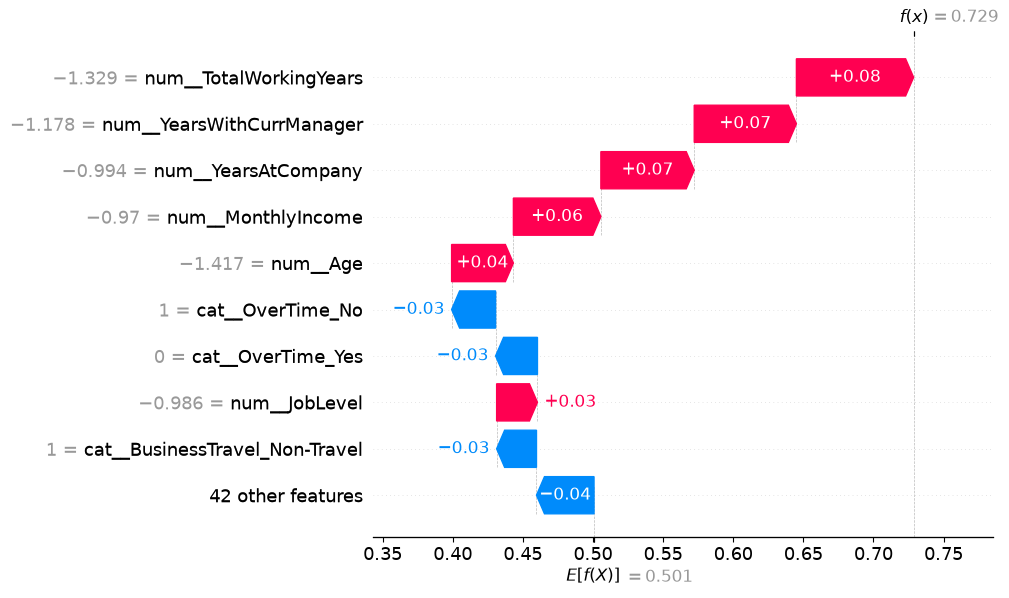

In [28]:
employee_index = 0

explanation = shap.Explanation(
    values=shap_values[employee_index, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_transformed[employee_index],
    feature_names=feature_names
)

shap.plots.waterfall(explanation, max_display=10)

In [29]:
probability = pipeline.predict_proba(X_test.iloc[[employee_index]])[0][1]

prediction = (
    "High Risk"
    if probability >= 0.35
    else "Low Risk"
)

report = {
    "Prediction": prediction,
    "Probability": round(probability, 4),
    "Top Factors": employee_shap.head(5).to_dict("records")
}

report

{'Prediction': 'High Risk',
 'Probability': np.float64(0.7286),
 'Top Factors': [{'Feature': 'num__TotalWorkingYears',
   'SHAP Value': 0.0836,
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'num__YearsWithCurrManager',
   'SHAP Value': 0.0729,
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'num__YearsAtCompany',
   'SHAP Value': 0.0666,
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'num__MonthlyIncome',
   'SHAP Value': 0.0624,
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'num__Age',
   'SHAP Value': 0.044,
   'Impact': 'Increases Attrition Risk'}]}

In [30]:
feature_mapping = {
    "num__TotalWorkingYears": "Total Working Years",
    "num__YearsWithCurrManager": "Years With Current Manager",
    "num__MonthlyIncome": "Monthly Income",
    "num__Age": "Age",
    "cat__OverTime_Yes": "OverTime = Yes",
    "cat__OverTime_No": "OverTime = No",
}

In [31]:
employee_shap["Feature"] = employee_shap["Feature"].replace(feature_mapping)

In [32]:
report = {
    "Prediction": prediction,
    "Probability": float(round(probability, 4)),
    "Threshold": 0.35,
    "Top Factors": employee_shap.head(5).to_dict("records")
}

report

{'Prediction': 'High Risk',
 'Probability': 0.7286,
 'Threshold': 0.35,
 'Top Factors': [{'Feature': 'Total Working Years',
   'SHAP Value': 0.0836,
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'Years With Current Manager',
   'SHAP Value': 0.0729,
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'num__YearsAtCompany',
   'SHAP Value': 0.0666,
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'Monthly Income',
   'SHAP Value': 0.0624,
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'Age',
   'SHAP Value': 0.044,
   'Impact': 'Increases Attrition Risk'}]}

In [33]:
employee_shap["SHAP Value"] = employee_shap["SHAP Value"].round(3)

In [34]:
def clean_feature_name(feature):

    feature = feature.replace("num__", "")
    feature = feature.replace("cat__", "")

    feature = feature.replace("YearsWithCurrManager", "Years With Current Manager")
    feature = feature.replace("YearsAtCompany", "Years At Company")
    feature = feature.replace("TotalWorkingYears", "Total Working Years")
    feature = feature.replace("MonthlyIncome", "Monthly Income")
    feature = feature.replace("JobLevel", "Job Level")
    feature = feature.replace("StockOptionLevel", "Stock Option Level")
    feature = feature.replace("EnvironmentSatisfaction", "Environment Satisfaction")
    feature = feature.replace("DistanceFromHome", "Distance From Home")
    feature = feature.replace("JobSatisfaction", "Job Satisfaction")
    feature = feature.replace("BusinessTravel_Non-Travel", "Business Travel = Non-Travel")
    feature = feature.replace("BusinessTravel_Travel_Frequently", "Business Travel = Frequently")
    feature = feature.replace("BusinessTravel_Travel_Rarely", "Business Travel = Rarely")
    feature = feature.replace("OverTime_Yes", "OverTime = Yes")
    feature = feature.replace("OverTime_No", "OverTime = No")
    feature = feature.replace("MaritalStatus_Single", "Marital Status = Single")
    feature = feature.replace("Department_Sales", "Department = Sales")
    feature = feature.replace("Department_Research & Development", "Department = R&D")

    return feature

In [35]:
employee_shap["Feature"] = employee_shap["Feature"].apply(clean_feature_name)

In [36]:
employee_shap["Direction"] = employee_shap["SHAP Value"].apply(
    lambda x: "Increase" if x > 0 else "Decrease"
)

In [37]:
report = {
    "Prediction": prediction,
    "Probability": float(round(probability, 4)),
    "Threshold": 0.35,
    "Top Factors": employee_shap[
        ["Feature", "SHAP Value", "Direction", "Impact"]
    ].head(5).to_dict("records")
}

report

{'Prediction': 'High Risk',
 'Probability': 0.7286,
 'Threshold': 0.35,
 'Top Factors': [{'Feature': 'Total Working Years',
   'SHAP Value': 0.084,
   'Direction': 'Increase',
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'Years With Current Manager',
   'SHAP Value': 0.073,
   'Direction': 'Increase',
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'Years At Company',
   'SHAP Value': 0.067,
   'Direction': 'Increase',
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'Monthly Income',
   'SHAP Value': 0.062,
   'Direction': 'Increase',
   'Impact': 'Increases Attrition Risk'},
  {'Feature': 'Age',
   'SHAP Value': 0.044,
   'Direction': 'Increase',
   'Impact': 'Increases Attrition Risk'}]}